In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Matplotlib renders plots inline inside the notebook
%matplotlib inline

# Set aesthetic visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

In [7]:
# Import the custom metrics module from src
import sys
sys.path.append('..')
from src.metrics import calculate_financial_health_metrics

# Load clean data
df_clean = pd.read_csv("../data/processed/banking_data_clean.csv")

# Enrich with strategic financial health metrics
df_enriched = calculate_financial_health_metrics(df_clean)

# Save the enriched dataset for Power BI in the next phase
df_enriched.to_csv("../data/processed/banking_data_enriched.csv", index=False)
print("Enriched dataset generated and saved.")

# Quick preview of dataset shape and columns
df_enriched.head()

ImportError: cannot import name 'RAW_DATA_PATH' from 'src.config' (d:\DLytica\DataAnalyst\nepal-banking-analytics\notebooks\..\src\config.py)

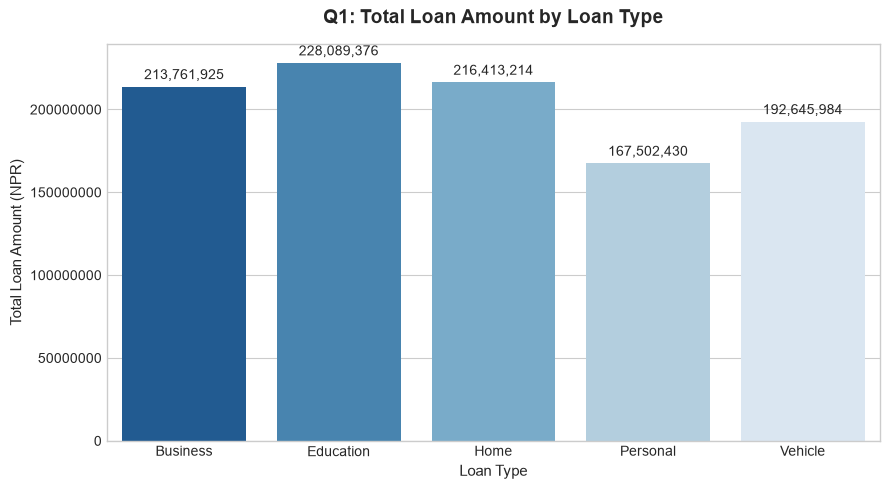

In [12]:
# Q1: Total Loan Amount by Loan Type
plt.figure(figsize=(9, 5))
loan_summary = df_enriched.groupby('Loan_Type')['Loan_Amount'].sum().reset_index()

ax = sns.barplot(data=loan_summary, x='Loan_Type', y='Loan_Amount', hue='Loan_Type', palette='Blues_r')
plt.title('Q1: Total Loan Amount by Loan Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Loan Type', fontsize=11)
plt.ylabel('Total Loan Amount (NPR)', fontsize=11)
plt.ticklabel_format(style='plain', axis='y')

# Annotate bar values inline
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()  # Displays directly inside the notebook cell!

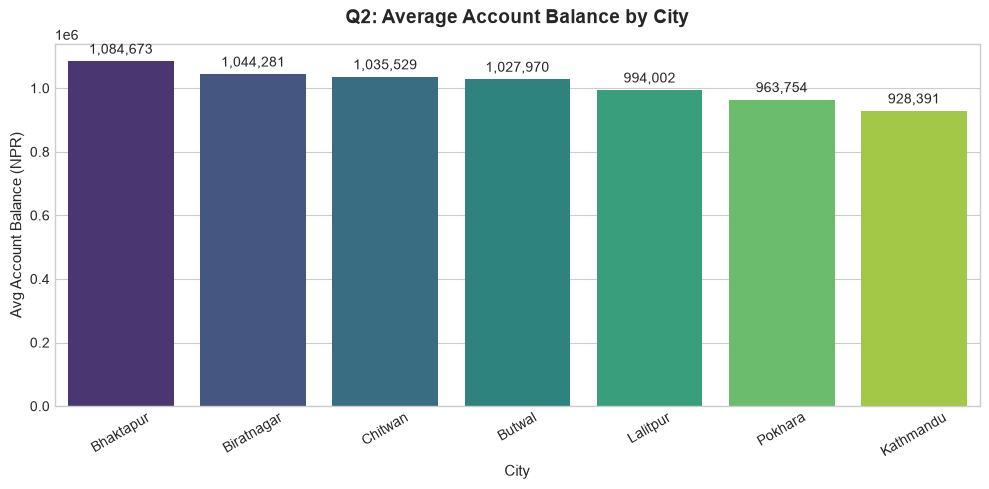

In [11]:
# Q2: Average Account Balance by City
plt.figure(figsize=(10, 5))
city_summary = df_enriched.groupby('City')['Account_Balance'].mean().sort_values(ascending=False).reset_index()

ax = sns.barplot(data=city_summary, x='City', y='Account_Balance', hue='City', palette='viridis')
plt.title('Q2: Average Account Balance by City', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=11)
plt.ylabel('Avg Account Balance (NPR)', fontsize=11)
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

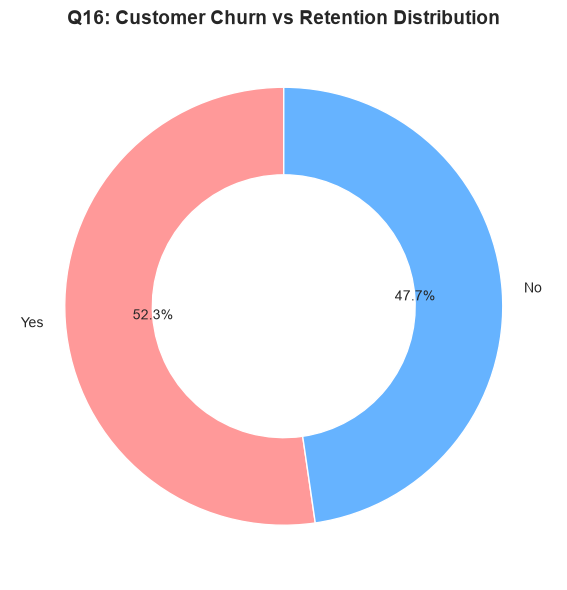

In [ ]:
# Q3: Customer Churn Rate Distribution
plt.figure(figsize=(6, 6))
churn_counts = df_enriched['Churn_Status'].value_counts()

plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999', '#66b3ff'], 
    wedgeprops=dict(width=0.4, edgecolor='w')
)
plt.title('Q3: Customer Churn vs Retention Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

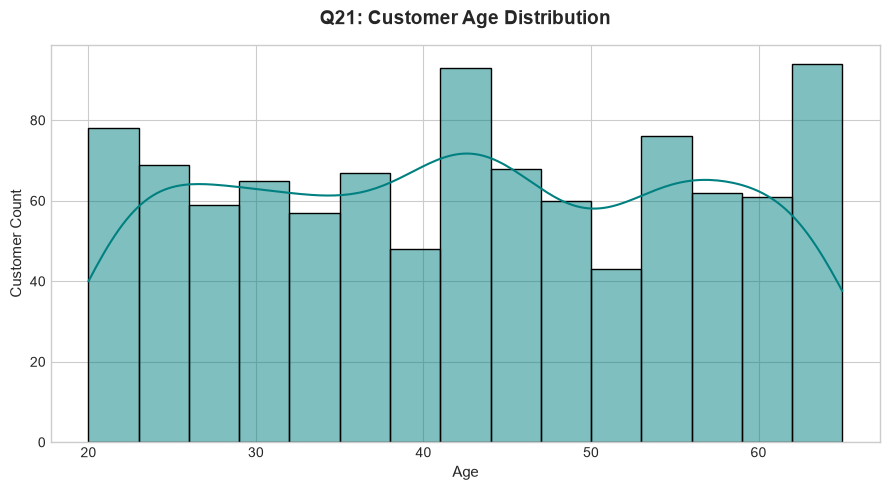

In [8]:
# Q4: Customer Age Distribution
plt.figure(figsize=(9, 5))
sns.histplot(df_enriched['Age'], bins=15, kde=True, color='teal')
plt.title('Q21: Customer Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=11)
plt.ylabel('Customer Count', fontsize=11)
plt.tight_layout()
plt.show()

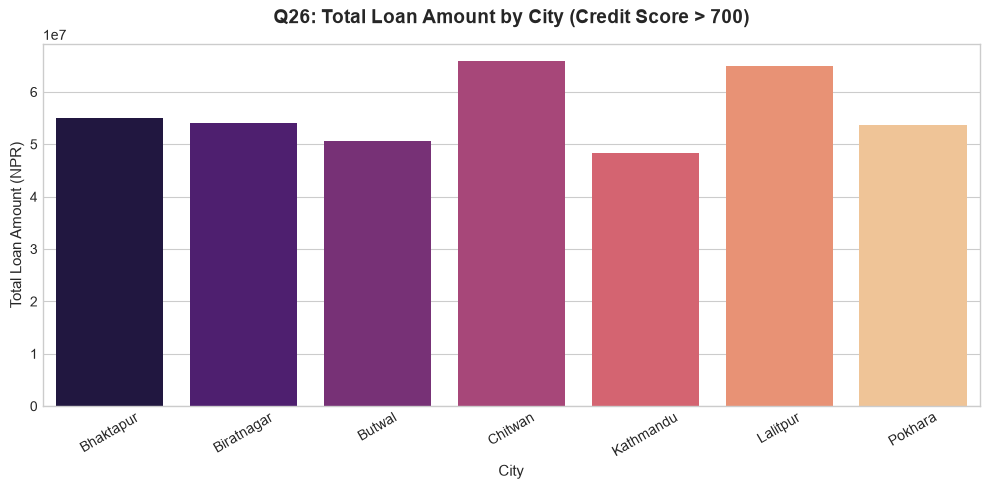

In [10]:
# Q5: Loan Amount by City (Credit Score > 700)
plt.figure(figsize=(10, 5))
high_credit_df = df_enriched[df_enriched['Credit_Score'] > 700]
high_credit_summary = high_credit_df.groupby('City')['Loan_Amount'].sum().reset_index()

sns.barplot(data=high_credit_summary, x='City', y='Loan_Amount', hue='City', palette='magma')
plt.title('Q26: Total Loan Amount by City (Credit Score > 700)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=11)
plt.ylabel('Total Loan Amount (NPR)', fontsize=11)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()